CUSTOMER CHURN PREDICTION
predciting whether a customer will leave a service or not using machine learning models and comparing their performances.


DATASET: Churn Modelling Dataset from Kaggle

Number of rows: 10000

Number of features: 14

In [150]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report,accuracy_score,roc_curve,auc, confusion_matrix



In [151]:
df= pd.read_csv(r"D:\DIGITIVITYTASK\Churn_Modelling.csv")
df.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [152]:
print(df.info())
print(df.shape)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None
(10000, 14)


In [153]:
print(df.isnull().sum())
print(df.columns)

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')


In [154]:
df['Gender']=LabelEncoder().fit_transform(df['Gender'])
df['Geography']=LabelEncoder().fit_transform(df['Geography'])
df=df.drop(['RowNumber', 'CustomerId','Surname'],axis=1)

                 CreditScore  Geography    Gender       Age    Tenure  \
CreditScore         1.000000   0.007888 -0.002857 -0.003965  0.000842   
Geography           0.007888   1.000000  0.004719  0.022812  0.003739   
Gender             -0.002857   0.004719  1.000000 -0.027544  0.014733   
Age                -0.003965   0.022812 -0.027544  1.000000 -0.009997   
Tenure              0.000842   0.003739  0.014733 -0.009997  1.000000   
Balance             0.006268   0.069408  0.012087  0.028308 -0.012254   
NumOfProducts       0.012238   0.003972 -0.021859 -0.030680  0.013444   
HasCrCard          -0.005458  -0.008523  0.005766 -0.011721  0.022583   
IsActiveMember      0.025651   0.006724  0.022544  0.085472 -0.028362   
EstimatedSalary    -0.001384  -0.001369 -0.008112 -0.007201  0.007784   
Exited             -0.027094   0.035943 -0.106512  0.285323 -0.014001   

                  Balance  NumOfProducts  HasCrCard  IsActiveMember  \
CreditScore      0.006268       0.012238  -0.005458 

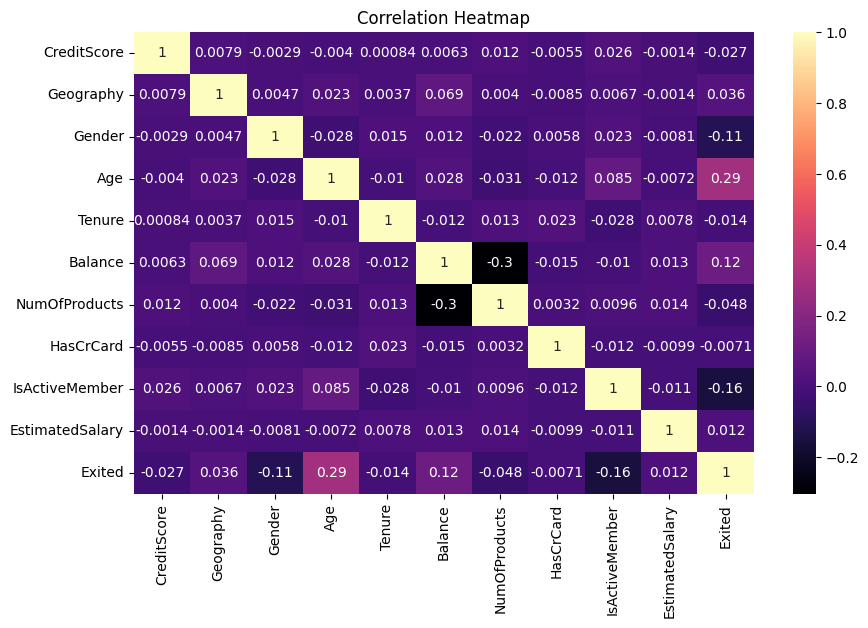

   CreditScore  Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619          0       0   42       2       0.00              1   
1          608          2       0   41       1   83807.86              1   
2          502          0       0   42       8  159660.80              3   
3          699          0       0   39       1       0.00              2   
4          850          2       0   43       2  125510.82              1   
5          645          2       1   44       8  113755.78              2   
6          822          0       1   50       7       0.00              2   
7          376          1       0   29       4  115046.74              4   
8          501          0       1   44       4  142051.07              2   
9          684          0       1   27       2  134603.88              1   

   HasCrCard  IsActiveMember  EstimatedSalary  Exited  
0          1               1        101348.88       1  
1          0               1        112542.58      

In [155]:
ini_corr=df.corr()
print(ini_corr)

plt.figure(figsize=(10,6))
sns.heatmap(ini_corr, annot=True, cmap='magma')
plt.title('Correlation Heatmap')
plt.show()

print(df.head(10))

In [156]:
df.rename(columns={
    'EstimatedSalary':'Income',
    'NumOfProducts':'Purchases',
    'IsActiveMember':'Membership',
    'Exited':'Churn'
}, inplace=True)
print(df.columns)

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'Purchases', 'HasCrCard', 'Membership', 'Income', 'Churn'],
      dtype='object')


The dataset contains useful features, but most individual columns have weak correlation with the target column('Churn'). To handle this, feature engineering is applied to create the relationship features that can capture combined patterns.
With these new features, the model will be able to learn and capture the patterns more efficiently.


balance_income_ratio, is_inactive_highbalance, age_group, products_per_creditscore.


Multicollinearlity is identified with Age and age_group with 0.92 correlation and CreditScore and prodcuts_per_creditscore with 0.91 correlation, therefore the original columns were dropped to avoid redundancy.


In [157]:
df['balance_income_ratio']=df['Balance']/ df['Income']
df['is_inactive_highbalance']=((df['Balance']>df['Balance'].median()) & (df['Membership']==0)).astype(int)
df['age_group']= pd.cut(df['Age'], bins=[0,30,45,60,100], labels=[0,1,2,3]).astype(int)
df['products_per_creditscore']= df['Purchases']/(df['CreditScore']+1)

In [158]:
df= df.drop(['CreditScore','Age'], axis=1)

df= df[['Geography','Gender','Balance','Purchases','Membership','Income','balance_income_ratio'
        ,'is_inactive_highbalance','age_group'
        ,'products_per_creditscore','Churn']]
X=df.drop('Churn',axis=1)
y=df['Churn']
print(X.head())
print(y.head())

   Geography  Gender    Balance  Purchases  Membership     Income  \
0          0       0       0.00          1           1  101348.88   
1          2       0   83807.86          1           1  112542.58   
2          0       0  159660.80          3           0  113931.57   
3          0       0       0.00          2           0   93826.63   
4          2       0  125510.82          1           1   79084.10   

   balance_income_ratio  is_inactive_highbalance  age_group  \
0              0.000000                        0          1   
1              0.744677                        0          1   
2              1.401375                        1          1   
3              0.000000                        0          1   
4              1.587055                        0          1   

   products_per_creditscore  
0                  0.001613  
1                  0.001642  
2                  0.005964  
3                  0.002857  
4                  0.001175  
0    1
1    0
2    1
3    

                          Geography    Gender   Balance  Purchases  \
Geography                  1.000000  0.004719  0.069408   0.003972   
Gender                     0.004719  1.000000  0.012087  -0.021859   
Balance                    0.069408  0.012087  1.000000  -0.304180   
Purchases                  0.003972 -0.021859 -0.304180   1.000000   
Membership                 0.006724  0.022544 -0.010084   0.009612   
Income                    -0.001369 -0.008112  0.012797   0.014204   
balance_income_ratio       0.002887  0.008384  0.027235  -0.015942   
is_inactive_highbalance    0.017712 -0.007110  0.499987  -0.146660   
age_group                  0.022950 -0.025131  0.030521  -0.036112   
products_per_creditscore   0.000098 -0.019540 -0.279749   0.912661   
Churn                      0.035943 -0.106512  0.118533  -0.047820   

                          Membership    Income  balance_income_ratio  \
Geography                   0.006724 -0.001369              0.002887   
Gender         

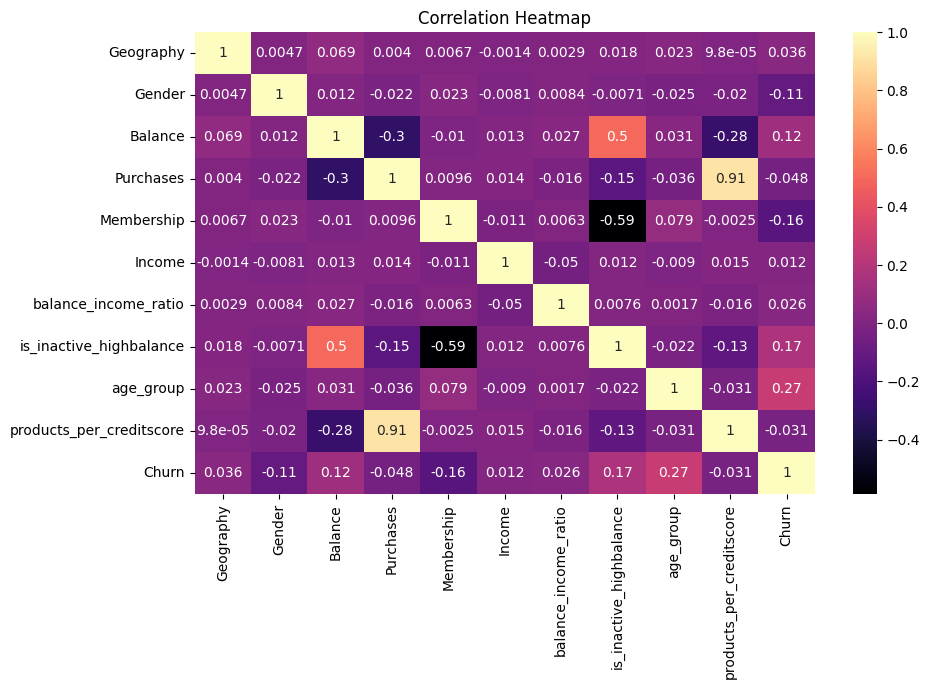

In [159]:
corr=df.corr()
print(corr)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='magma')
plt.title('Correlation Heatmap')
plt.show()

Boxplot analysis for Outlier Detection
There is no significant outliers in the dataset. Balance and Income show the wide distribution which shows the customer variation.
A single extreme value is observed in Income which is negligible.

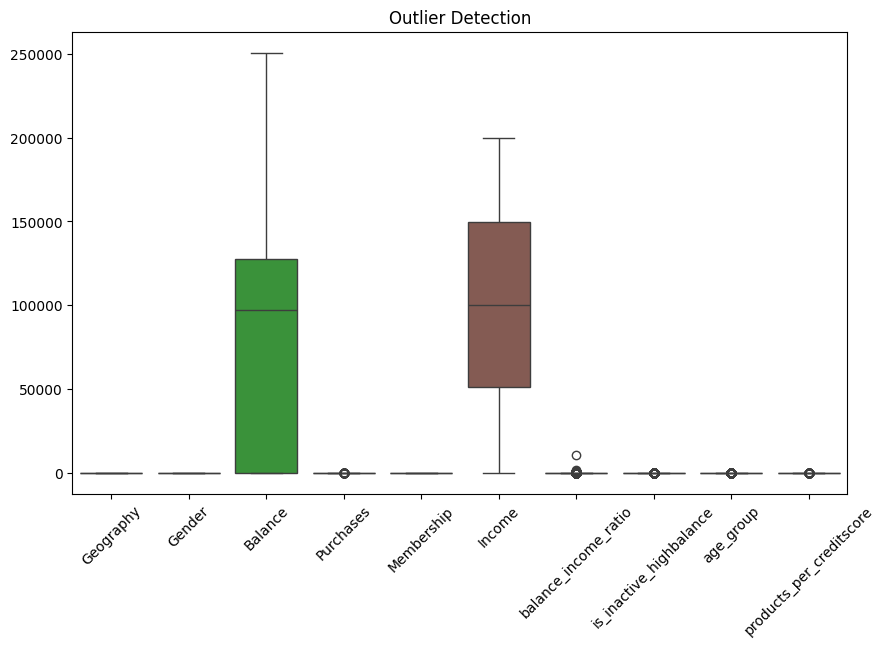

In [211]:
plt.figure(figsize=(10,6))
sns.boxplot(data=X)
plt.xticks(rotation=45)
plt.title("Outlier Detection")
plt.show()

In [160]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True)*100)


Churn
0    7963
1    2037
Name: count, dtype: int64
Churn
0    79.63
1    20.37
Name: proportion, dtype: float64


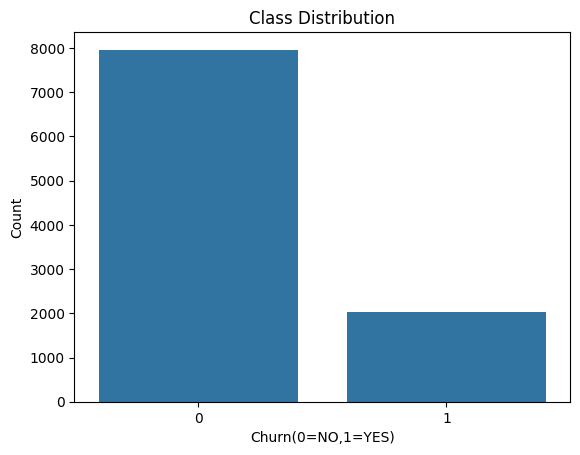

In [161]:
sns.countplot(x='Churn',data=df)
plt.title("Class Distribution")
plt.xlabel("Churn(0=NO,1=YES)")
plt.ylabel("Count")
plt.show()

There's a class imabalnce noticed in the dataset, with a higher proportion of non-churn customers(80:20 ratio). This can lead to biased predictions where the model favors the majority class(non-churn), reducing the ability to correctly identity churn cases.

Feature Scaling is done, to make sure that all variables contribute equally to the model training. Scaling prevents large-value features from domainating the model.

The dataset can be balanced to make sure the model doesnt make any biased predictions using oversampling techniques like SMOTE after scaling the data.(Synthetic Minority Oversampling Technique).

In [162]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train,y_test = train_test_split(X,y, random_state=42,stratify=y)
scaler = StandardScaler()

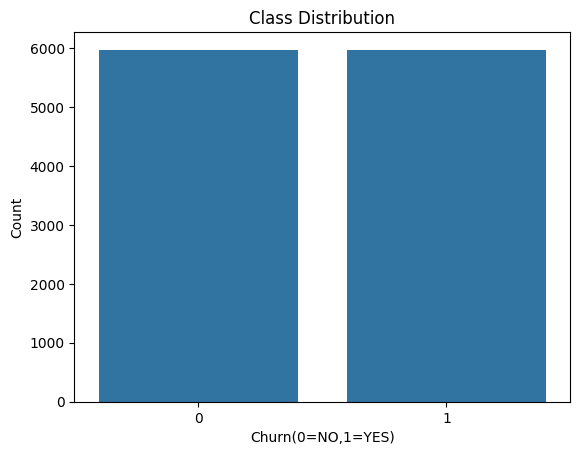

In [163]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
sm=SMOTE(random_state=42)
X_resampled,y_resampled = sm.fit_resample(X_train_scaled,y_train)

sns.countplot(x='y_resampled',data=pd.DataFrame({'y_resampled': y_resampled}))
plt.title("Class Distribution")
plt.xlabel("Churn(0=NO,1=YES)")
plt.ylabel("Count")
plt.show()

MODEL 1: LOGISTIC REGRESSION


LR is taken as the base model because of its less-complex nature.It works by finding linear decision-bundry between the classes. While it may not capture complex patterns, feature engineering helps the model to learn complex patterns.

Without Smote

In [164]:
from sklearn.linear_model import LogisticRegression
lr =LogisticRegression()

lr.fit(X_train_scaled,y_train)
y_pred_lr1= lr.predict(X_test_scaled)
print("Accuracy:",accuracy_score(y_test,y_pred_lr1))
print("Classification_Report:",classification_report(y_test,y_pred_lr1))

Accuracy: 0.8136
Classification_Report:               precision    recall  f1-score   support

           0       0.82      0.98      0.89      1991
           1       0.67      0.17      0.27       509

    accuracy                           0.81      2500
   macro avg       0.74      0.57      0.58      2500
weighted avg       0.79      0.81      0.77      2500



Without Smote LR achieves a recall of only 0.17 for churners, which indicates that the model is heavily biased toward the majority class(non-churners).
This makes it unreliable for churn detection without resampling.

[[1948   43]
 [ 423   86]]


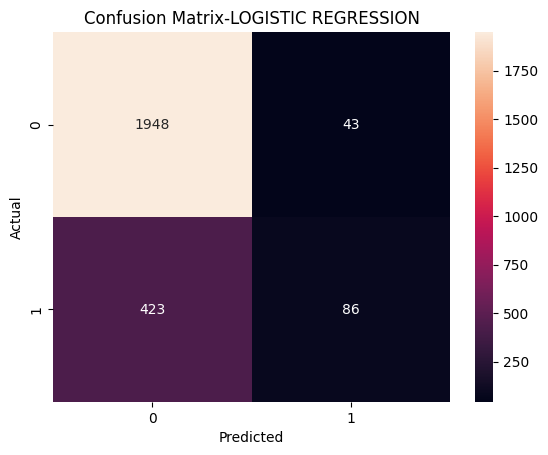

In [165]:
cm_lf1 = confusion_matrix(y_test,y_pred_lr1)
print(cm_lf1)
sns.heatmap(cm_lf1,annot=True,fmt='d')
plt.title("Confusion Matrix-LOGISTIC REGRESSION")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


With SMOTE

In [166]:
from sklearn.linear_model import LogisticRegression
lr =LogisticRegression()

lr.fit(X_resampled,y_resampled)
y_pred_lr= lr.predict(X_test_scaled)
y_train_pred = lr.predict(X_resampled)
print("Train Accuracy:",accuracy_score(y_resampled,y_train_pred))
print("Accuracy:",accuracy_score(y_test,y_pred_lr))

print("Classification_Report:",classification_report(y_test,y_pred_lr))

Train Accuracy: 0.6743134628265238
Accuracy: 0.6844
Classification_Report:               precision    recall  f1-score   support

           0       0.90      0.68      0.77      1991
           1       0.36      0.70      0.48       509

    accuracy                           0.68      2500
   macro avg       0.63      0.69      0.62      2500
weighted avg       0.79      0.68      0.71      2500



With SMOTE being applied LR shows a significant improvement in the recall for churners( increased from 0.17 to 0.70). However the overall accuracy dropped to 0.68 and the precision of class 1 indicates increase in false positives. But the train and test accuracies shows that the model could generalise with no overfitting.

[[1353  638]
 [ 151  358]]


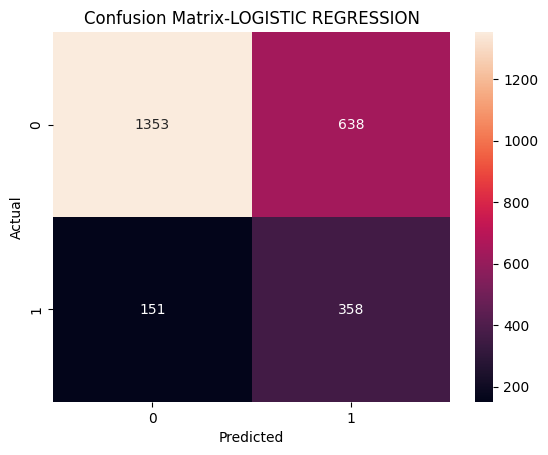

In [167]:
cm_lf = confusion_matrix(y_test,y_pred_lr)
print(cm_lf)
sns.heatmap(cm_lf,annot=True,fmt='d')
plt.title("Confusion Matrix-LOGISTIC REGRESSION")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


MODEL 2: RANDOM FOREST CLASSIFIER

Random Forest is an ensemble of decision trees. It has the ability to handle non-linear relationships, robust to noisy features and has feature importance.

In [168]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators= 100,max_depth=10,min_samples_split=10,random_state=42)
rf_clf.fit(X_resampled,y_resampled)


,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [169]:
y_train_pred=rf_clf.predict(X_resampled)
y_pred_rf=rf_clf.predict(X_test_scaled)
print("Train Accuracy:",accuracy_score(y_resampled,y_train_pred))

print("Accuracy:",accuracy_score(y_test,y_pred_rf))
print("Classification Report:",classification_report(y_test,y_pred_rf))



Train Accuracy: 0.8624413931681179
Accuracy: 0.7996
Classification Report:               precision    recall  f1-score   support

           0       0.91      0.83      0.87      1991
           1       0.51      0.70      0.59       509

    accuracy                           0.80      2500
   macro avg       0.71      0.76      0.73      2500
weighted avg       0.83      0.80      0.81      2500



Random Forest outperforms LR significantly on F1-score for churners. The train-test gap shows mild overfitting but it shows the model is able to generalise well.

the parameters like 'max_depth' and 'min_samples_split; were kept to 10, to control overfitting from the start.

[[1645  346]
 [ 155  354]]


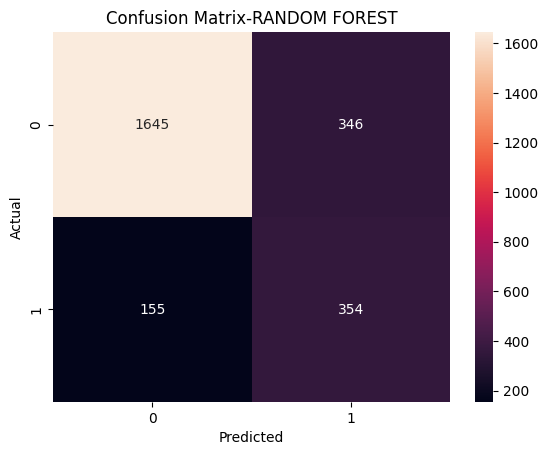

In [170]:
cm_rf = confusion_matrix(y_test,y_pred_rf)
print(cm_rf)

sns.heatmap(cm_rf, annot=True,fmt='d')
plt.title("Confusion Matrix-RANDOM FOREST")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

MODEL 3 - XGBoost

XGBoost is a gradient boosting algorithm that builds trees sequentially, where each tree corrects the mistakes(errors) of the previous one.

In [171]:
from xgboost import XGBClassifier
xgb_clf= XGBClassifier(use_label_encoder=False,max_depth=5, eval_metric='logloss',random_state=42)

xgb_clf.fit(X_resampled,y_resampled)

c:\Users\Bhuvana\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [11:40:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [177]:
y_pred_xgb= xgb_clf.predict(X_test_scaled)
y_train_pred_xgb=xgb_clf.predict(X_resampled)
print("Train Accuracy:",accuracy_score(y_resampled,y_train_pred_xgb))
print("Accuracy:",accuracy_score(y_test,y_pred_xgb))


print("Classification Report:", classification_report(y_test,y_pred_xgb))


Train Accuracy: 0.8980241125251173
Accuracy: 0.7996
Classification Report:               precision    recall  f1-score   support

           0       0.91      0.83      0.87      1991
           1       0.51      0.69      0.58       509

    accuracy                           0.80      2500
   macro avg       0.71      0.76      0.73      2500
weighted avg       0.83      0.80      0.81      2500



XGBoost performs comparably to RF. 
The recall of non-churners is 0.69, meaning it correctly idesntifies 69% of the customers who actually left. There's a mild overfitting issue, which could be the result of training on resampled data(using SMOTE).
Compared to LR, XGBoost  shows significantly better f1-score for churners, which shows that gradient boosting captures non-linear patterns more effectively than a linear model.

[[1560  431]
 [ 174  335]]


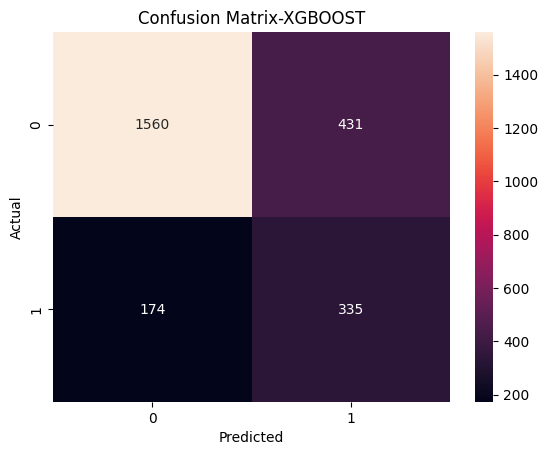

In [ ]:
cm_xgb= confusion_matrix(y_test,y_pred_xgb)
print(cm_xgb)

sns.heatmap(cm_xgb, annot=True,fmt='d')
plt.title("Confusion Matrix-XGBOOST")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()  

HYPERPARAMETER TUNING USING RANDOM SEARCH

Random Search was used over Grid Search for its efficiency.
Random Search randomly samples from the parameter space rather then exhaustively trying all combinations.

Initially the tuning was performed directly on the SMOTE applied training data. But this affected the models in such a way that, as they were trained on SMOTE data, the parameters found from tuning fit the synthetic patterns rathern than the actual customer behavior which lead to a bit poor generalisation.

After analysing the overfitting pattern, I tried changing the tuning strategy. First fitted the RandomizedSearchCV to find the parameters that works best on the scaled data. The best parametrs were then used to retrain the models on the SMOTE data.
This improved the generalization than the initial approach.

TUNING RANDOM FOREST - USING RANDOMSEARCHCV

In [217]:
from sklearn.model_selection import RandomizedSearchCV

rf_params={
    'n_estimators':[100,200,300,500],
    'max_depth':[5,10,15],
    'min_samples_split':[2,5,10],
    'min_samples_leaf': [4,8,16]
    }

rf_fclf=RandomizedSearchCV(rf_clf, rf_params,n_iter=15,n_jobs=-1,cv=3,random_state=42)
rf_fclf.fit(X_train_scaled,y_train)

best_rf_params=rf_fclf.best_params_

In [218]:
best_rf = RandomForestClassifier(**best_rf_params,random_state=42)
best_rf.fit(X_resampled,y_resampled)

y_pred_rf_tuned= best_rf.predict(X_test_scaled)
y_train_pred_rf=best_rf.predict(X_resampled)
print("Tuned Train Accuracy:",accuracy_score(y_resampled, y_train_pred_rf))
print("Tuned RF Accuracy:",accuracy_score(y_test,y_pred_rf_tuned))


print("Tuned RF Classificaition Report:", classification_report(y_test,y_pred_rf_tuned))

Tuned Train Accuracy: 0.8861352980576022
Tuned RF Accuracy: 0.8068
Tuned RF Classificaition Report:               precision    recall  f1-score   support

           0       0.92      0.83      0.87      1991
           1       0.52      0.70      0.60       509

    accuracy                           0.81      2500
   macro avg       0.72      0.77      0.73      2500
weighted avg       0.83      0.81      0.82      2500



Compared to base RF, tuning slightly improved the accuracy and F1 score.
The train-test gap still implies mild overfitting but better than the base RF

TUNING XGB-RANDOMSEARCHCV

In [220]:
from scipy.stats import randint, uniform
xgb_params={
    'n_estimators':[100,200,300],
    'max_depth':[3,7,10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'reg_alpha':[0,0.3,0.5,0.10],
    'subsample': [0.6,0.4]   
    
}

xgb_fclf=RandomizedSearchCV(xgb_clf,xgb_params,n_iter=15,cv=3,n_jobs=-1,random_state=42)
xgb_fclf.fit(X_train_scaled,y_train)
best_xgb_p=xgb_fclf.best_params_


c:\Users\Bhuvana\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [14:50:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [223]:

best_xgb= XGBClassifier(**best_xgb_p,eval_metric='logloss',random_state=42)
best_xgb.fit(X_resampled,y_resampled)
y_pred_xgb_tuned= best_xgb.predict(X_test_scaled)
y_train_pred_xgb=best_xgb.predict(X_resampled)
print("Tuned Train Accuracy:",accuracy_score(y_resampled,y_train_pred_xgb))
print("Tuned XGB Accuracy:",accuracy_score(y_test,y_pred_xgb_tuned))


print("Tuned XGB Classificaition Report:", classification_report(y_test,y_pred_xgb_tuned))

Tuned Train Accuracy: 0.8401707970529136
Tuned XGB Accuracy: 0.806
Tuned XGB Classificaition Report:               precision    recall  f1-score   support

           0       0.92      0.83      0.87      1991
           1       0.52      0.71      0.60       509

    accuracy                           0.81      2500
   macro avg       0.72      0.77      0.74      2500
weighted avg       0.84      0.81      0.82      2500



The tuning strategy had good improved impact on the XGBoost more, where the training accuracy dropped from 0.95 to 0.84 , indicating that the model stopped overfiiting to synthetic data and learned generalisable patterns.

COMPARISON

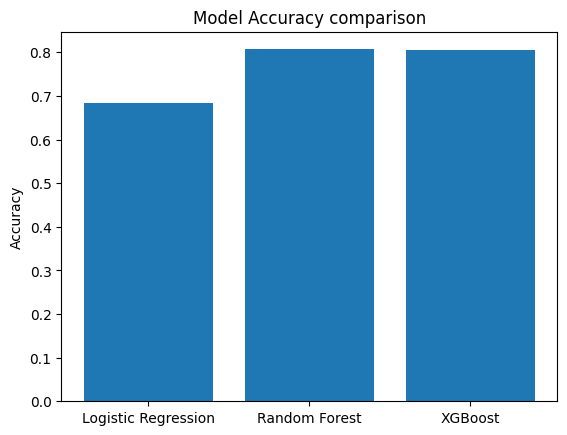

In [224]:
acc_lr=accuracy_score(y_test,y_pred_lr)
acc_rf=accuracy_score(y_test,y_pred_rf_tuned)
acc_xgb=accuracy_score(y_test,y_pred_xgb_tuned)

models=['Logistic Regression', 'Random Forest', 'XGBoost']
accuracies=[acc_lr,acc_rf,acc_xgb]
plt.bar(models,accuracies)
plt.title("Model Accuracy comparison")
plt.ylabel("Accuracy")
plt.show()

FINAL COMPARISON - PR-CURVES

In [225]:
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]
y_prob_rf = best_rf.predict_proba(X_test_scaled)[:,1]
y_prob_xgb = best_xgb.predict_proba(X_test_scaled)[:,1]



In [226]:
from sklearn.metrics import precision_recall_curve, auc

prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_prob_lr)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_prob_rf)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)

auc_lr = auc(rec_lr, prec_lr)
auc_rf = auc(rec_rf, prec_rf)
auc_xgb = auc(rec_xgb, prec_xgb)


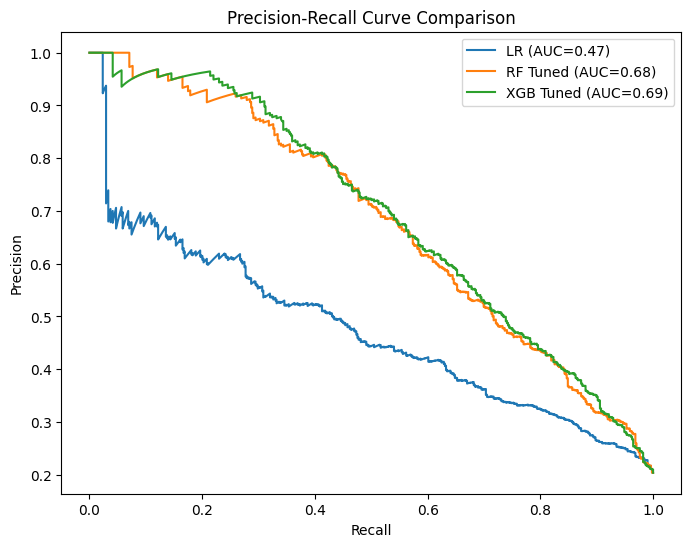

In [227]:
plt.figure(figsize=(8,6))

plt.plot(rec_lr, prec_lr, label=f"LR (AUC={auc_lr:.2f})")
plt.plot(rec_rf, prec_rf, label=f"RF Tuned (AUC={auc_rf:.2f})")
plt.plot(rec_xgb, prec_xgb, label=f"XGB Tuned (AUC={auc_xgb:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.show()

In [231]:
from sklearn.metrics import f1_score

f1_lr = f1_score(y_test, y_pred_lr)
f1_rf = f1_score(y_test, y_pred_rf_tuned)
f1_xgb = f1_score(y_test,y_pred_xgb_tuned)

print("F1 Scores:")
print("LR:", f1_lr)
print("RF Tuned:", f1_rf)
print("XGB Tuned:", f1_xgb)

F1 Scores:
LR: 0.4757475083056478
RF Tuned: 0.59581589958159
XGB Tuned: 0.5988420181968569


                 Model  F1 Score
0  Logistic Regression  0.475748
1  Random Forest Tuned  0.595816
2        XGBoost Tuned  0.598842


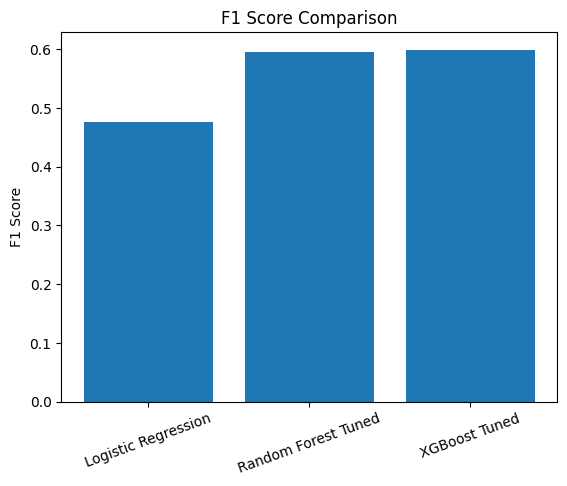

In [232]:
import pandas as pd

df_f1 = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest Tuned', 'XGBoost Tuned'],
    'F1 Score': [f1_lr, f1_rf, f1_xgb]
})

print(df_f1)
import matplotlib.pyplot as plt

plt.bar(df_f1['Model'], df_f1['F1 Score'])
plt.title("F1 Score Comparison")
plt.ylabel("F1 Score")
plt.xticks(rotation=20)
plt.show()

The PR Curve is the most meaningful metric to evaluate on for an imbalanced dataset as it focuses on the model's ability to identify churners.

XGB edges out RF with PR-AUC of 0.69, whcih confirms that the XGBoost works better for the churn identification.
Combined with lower train-test gap(0.03) and with the highest recall of 0.71, The tuned XGBoost model works the best.

RULE-BASED APPROACH.

major rules are:
Rule 1: The person is Aged and is not Active member
Rule 2: The person has high balance but they are not an active member
Rule 3: The purchases of a person is high and they are inactive
Rule 4: Their purchases are low and inactive(low engagement)
Rule 5: The purchases they made are high relative to low credit score and   they are also inactive.

In [244]:
def churn_rule_based(row):
    if row['age_group']>=2 and row['Membership']==0:
        return 1
    if row['Balance']>200000 and row['Membership'] ==0:
        return 1
    if row['Purchases'] >=3 and row['Membership']==0:
        return 1
    if row['Purchases'] == 1 and row['Membership'] ==0:
        return 1
    if row['products_per_creditscore'] > 0.03 and row['Membership']==0:
        return 1
    return 0

df['Rule_Prediction'] =df.apply(churn_rule_based,axis=1)


In [245]:
print("Rule Based Accuracy:",accuracy_score(df['Churn'],df['Rule_Prediction']))
print("Classification Report:",classification_report(df['Churn'],df['Rule_Prediction']))

Rule Based Accuracy: 0.7387
Classification Report:               precision    recall  f1-score   support

           0       0.88      0.78      0.83      7963
           1       0.40      0.58      0.47      2037

    accuracy                           0.74     10000
   macro avg       0.64      0.68      0.65     10000
weighted avg       0.78      0.74      0.75     10000



In [246]:
print(df['Rule_Prediction'].value_counts())

Rule_Prediction
0    7064
1    2936
Name: count, dtype: int64
